Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
=== 基礎統計量 ===
       char_count  line_count  avg_chars_per_line
count       657.0       657.0               657.0
mean       5733.6       251.5                25.4
std        5748.0       292.3                12.4
min           5.0         1.0                 5.0
25%        1504.0        68.0                17.4
50%        3975.0       156.0                22.3
75%        7965.0       329.0                30.7
max       34897.0      2280.0               108.5

=== 最大文字数（トップ5） ===
     index                     title  char_count
126    126  図書室にて47: GPT-5.4（34556字）       34897
517    517      アプリケーション構造Fugue (風雅)       33425
372    372               図書室にて21:実績1       31865
320    320             MoEデバッグReport       30591
7        7       図書室にて31: わたし島🏝️干拓事業       30231


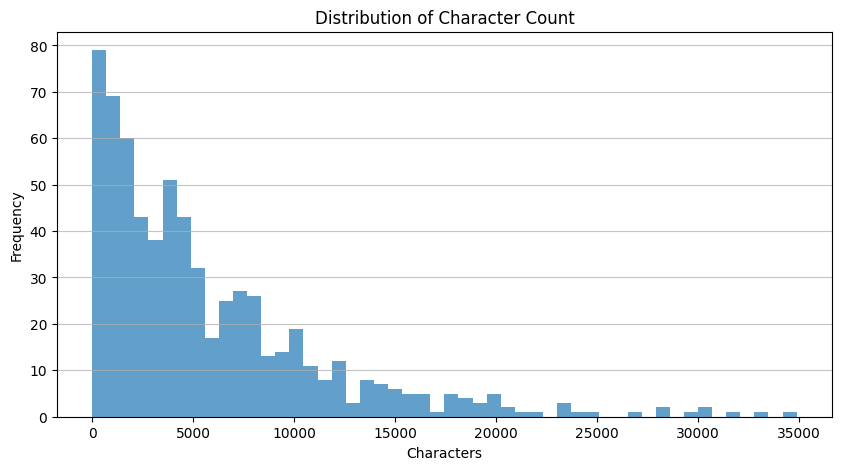

In [4]:
# 0. 「呪文」（Google Driveのマウント）
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
import json
import matplotlib.pyplot as plt

file_path = '/content/drive/MyDrive/note_corpus.jsonl' # ファイルパスを修正
data = []

# JSONLのロードと基礎集計
with open(file_path, 'r', encoding='utf-8') as f:
    for i, line in enumerate(f):
        item = json.loads(line)
        body = item.get('body', '')
        data.append({
            'index': i,
            'title': item.get('title', ''),
            'char_count': len(body),
            'line_count': body.count('\n') + 1,
        })

df = pd.DataFrame(data)
df['avg_chars_per_line'] = df['char_count'] / df['line_count']

# 基本統計量の出力
print("=== 基礎統計量 ===")
print(df[['char_count', 'line_count', 'avg_chars_per_line']].describe().round(1))

# 長文トップ5の抽出 (2万字の特定)
print("\n=== 最大文字数（トップ5） ===")
print(df.sort_values('char_count', ascending=False).head(5)[['index', 'title', 'char_count']])

# 分布の可視化
df['char_count'].plot.hist(bins=50, alpha=0.7, figsize=(10, 5))
plt.title('Distribution of Character Count')
plt.xlabel('Characters')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.75)
plt.show()

In [5]:
# 文字数分布データをCSVとしてエクスポート
output_file_path = '/content/drive/MyDrive/char_count_distribution.csv'
df[['index', 'title', 'char_count', 'line_count', 'avg_chars_per_line']].to_csv(output_file_path, index=False, encoding='utf-8-sig')

print(f"文字数分布データを '{output_file_path}' にエクスポートしました。")

文字数分布データを '/content/drive/MyDrive/char_count_distribution.csv' にエクスポートしました。
